# Calibration
rider_rate_hat (/hr)  = 34.5971
driver_rate_hat (/hr) = 4.7433
online Unif(q10,q90)   = Unif(6.20, 7.80)
mult   Unif(q10,q90)   = Unif(0.76, 1.24)
hotspot (x,y)          = (8.3597, 12.3175)

# KS check (Exponential inter-arrivals, modified KS)
conf level             = 0.950
critical value         = 1.094
rider:  D=0.0023, T=0.4331
driver: D=0.0104, T=0.7159


# Uniform check: Online duration (hr): Unif(q10,q90)
support [a,b]      = [6.2014, 7.79998]
trimmed n          = 3775
bins k             = 10
df (=k-d-1)        = 7  (d=2)
chi2 statistic     = 4.94967
critical (1-alpha) = 14.0671  (alpha=0.05)
p-value            = 0.666105


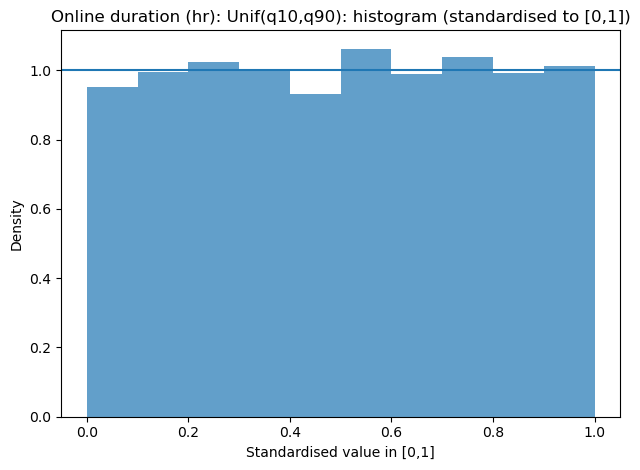

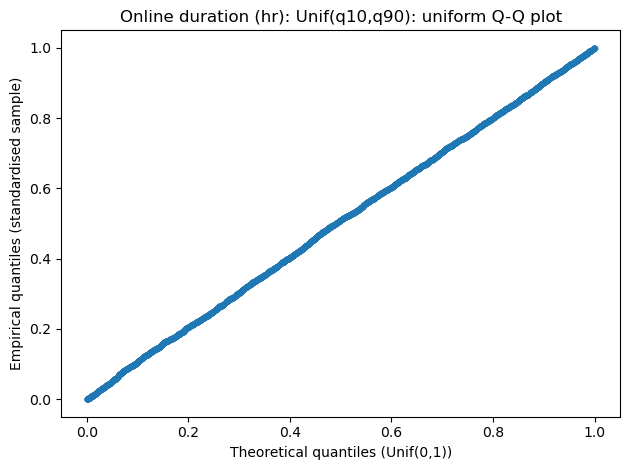


# Uniform check: Travel multiplier: Unif(m10,m90)
support [a,b]      = [0.761135, 1.23992]
trimmed n          = 27293
bins k             = 10
df (=k-d-1)        = 7  (d=2)
chi2 statistic     = 9.07709
critical (1-alpha) = 14.0671  (alpha=0.05)
p-value            = 0.247169


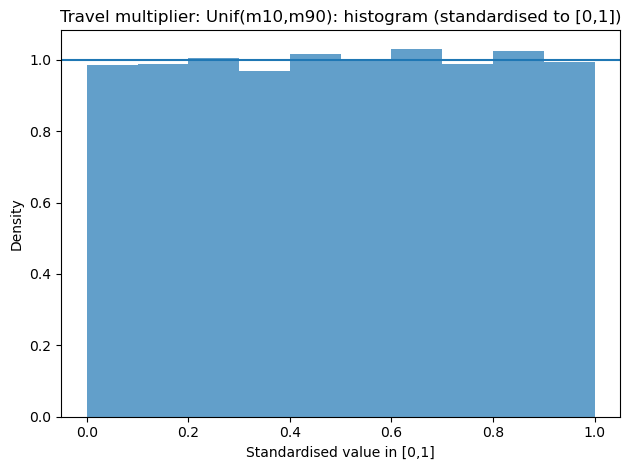

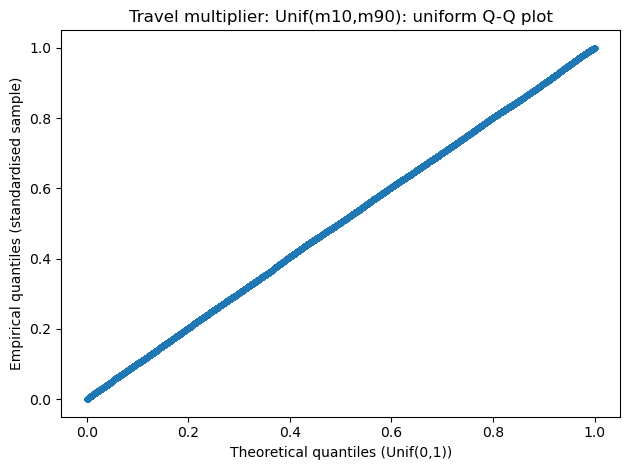

Online duration: {'n': 3775.0, 'k': 10.0, 'df': 7.0, 'chi2': 4.949668874172186, 'crit': 14.067140449340169, 'pval': 0.6661054562202036}
Multiplier: {'n': 27293.0, 'k': 10.0, 'df': 7.0, 'chi2': 9.077089363573076, 'crit': 14.067140449340169, 'pval': 0.24716864702948782}



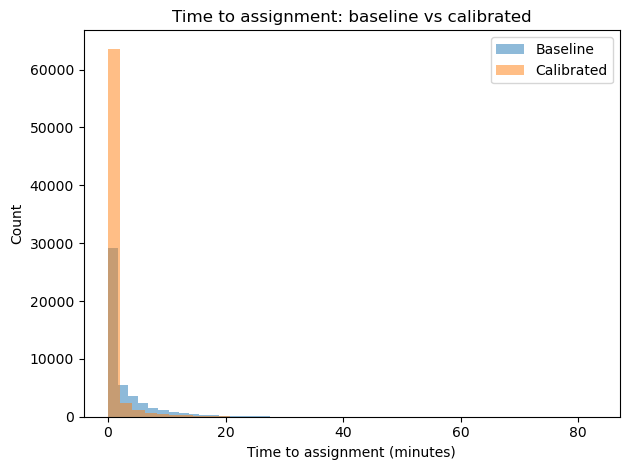

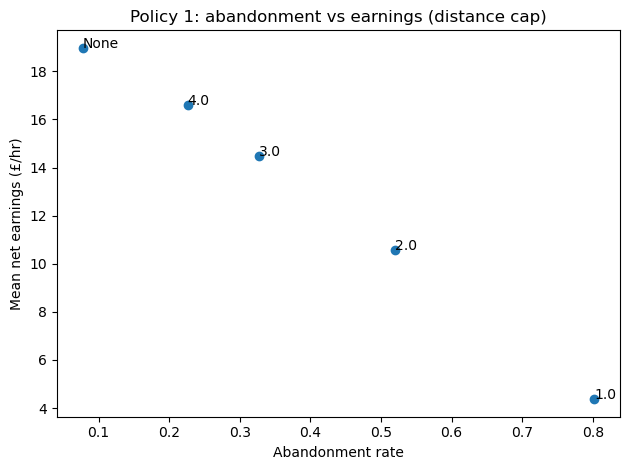

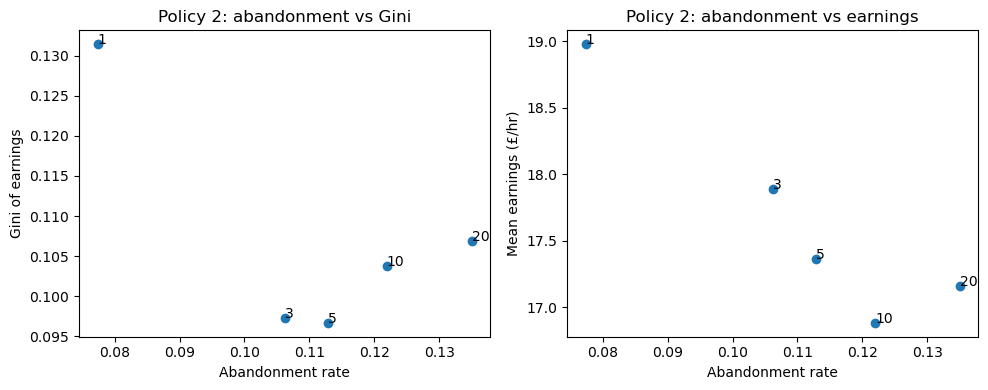

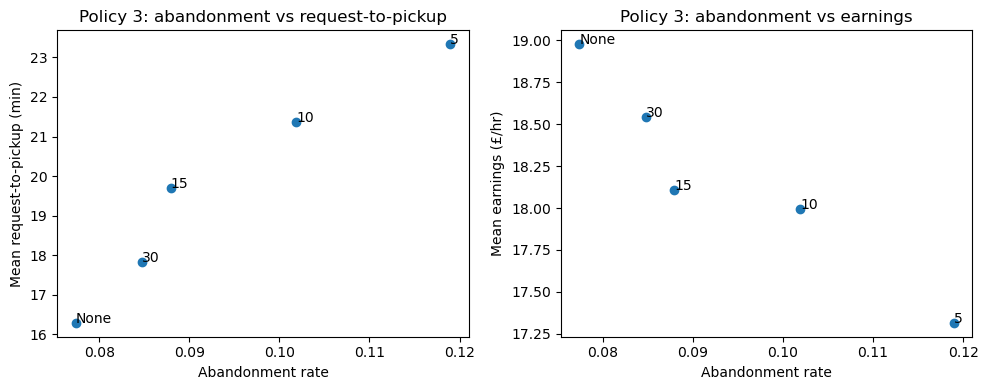

In [3]:
import os
import math
import heapq
import random
import ast
import argparse
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2


# ------------------------------------------------------------
# Small helpers
# ------------------------------------------------------------
def exp_time(rate_per_hour: float, rng: random.Random) -> float:
    return rng.expovariate(rate_per_hour)


def uniform(a: float, b: float, rng: random.Random) -> float:
    return a + (b - a) * rng.random()


def rand_point(L: float, rng: random.Random) -> Tuple[float, float]:
    return (uniform(0.0, L, rng), uniform(0.0, L, rng))


def dist(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    return math.hypot(a[0] - b[0], a[1] - b[1])


def parse_point(v: Any) -> Tuple[float, float]:
    # Accept "(x,y)" strings, tuples, or lists. Otherwise return NaNs.
    if v is None:
        return (float("nan"), float("nan"))
    if isinstance(v, float) and math.isnan(v):
        return (float("nan"), float("nan"))
    if isinstance(v, (tuple, list)) and len(v) >= 2:
        return (float(v[0]), float(v[1]))
    if isinstance(v, str):
        try:
            t = ast.literal_eval(v)
            if isinstance(t, (tuple, list)) and len(t) >= 2:
                return (float(t[0]), float(t[1]))
        except Exception:
            pass
    return (float("nan"), float("nan"))


def gini(values: List[float]) -> float:
    xs = [v for v in values if v is not None and not (isinstance(v, float) and math.isnan(v))]
    n = len(xs)
    if n == 0:
        return float("nan")

    xs.sort()
    s = sum(xs)
    if abs(s) < 1e-12:
        return 0.0

    cum = 0.0
    for i, x in enumerate(xs, start=1):
        cum += i * x
    return (2.0 * cum) / (n * s) - (n + 1.0) / n


# ------------------------------------------------------------
# KS test helpers
# ------------------------------------------------------------
def ks_distance(sample: np.ndarray, cdf_func) -> float:
    x = np.sort(np.asarray(sample, dtype=float))
    n = len(x)
    if n == 0:
        return float("nan")

    F = np.array([cdf_func(v) for v in x], dtype=float)
    i = np.arange(1, n + 1)

    D_plus = np.max(i / n - F)
    D_minus = np.max(F - (i - 1) / n)
    return float(max(D_plus, D_minus))


def ks_modified_stat_expon_mle(D: float, n: int) -> float:
    # Exponential(1/Xbar): modified KS statistic
    if not np.isfinite(D) or n <= 0:
        return float("nan")
    adj = max(D - 0.2 / n, 0.0)
    return float(adj * (math.sqrt(n) + 0.26 + math.sqrt(0.5 / n)))


def ks_critical_expon_mle(conf_level: float) -> float:
    # Exponential(1/Xbar): critical values table
    table = {0.90: 0.99, 0.95: 1.094, 0.975: 1.190}
    if conf_level not in table:
        raise ValueError(f"Unsupported KS confidence level {conf_level}. Use one of {sorted(table)}.")
    return table[conf_level]


# ------------------------------------------------------------
# DES entities
# ------------------------------------------------------------
@dataclass
class Rider:
    rid: int
    request_t: float
    origin: Tuple[float, float]
    dest: Tuple[float, float]
    patience_deadline: float
    matched: bool = False
    canceled: bool = False
    assignment_t: Optional[float] = None
    pickup_t: Optional[float] = None
    driver_id: Optional[int] = None


@dataclass
class Driver:
    did: int
    online_start: float
    planned_offline: float
    loc: Tuple[float, float]
    status: str = "idle"  # idle / busy / offline
    offline_pending: bool = False
    actual_offline: Optional[float] = None
    last_state_change: float = 0.0
    idle_time: float = 0.0
    busy_time: float = 0.0
    fare_total: float = 0.0
    petrol_total: float = 0.0
    reposition_token: int = 0


# ------------------------------------------------------------
# BoxCar DES
# ------------------------------------------------------------
class BoxCarDES:
    RIDER_ARRIVAL = "RiderArrival"
    DRIVER_ONLINE = "DriverOnline"
    RIDER_ABANDON = "RiderAbandon"
    PICKUP_COMPLETE = "PickupComplete"
    DROPOFF_COMPLETE = "DropoffComplete"
    DRIVER_OFFLINE_ATTEMPT = "DriverOfflineAttempt"
    REPOSITION_TRIGGER = "RepositionTrigger"
    REPOSITION_COMPLETE = "RepositionComplete"

    def __init__(self, params: Dict[str, Any], seed: int = 0):
        self.p = params
        self.rng = random.Random(seed)

        self.now = 0.0
        self.event_seq = 0
        self.q: List[Tuple[float, int, int, str, Any]] = []

        self.next_rider_id = 1
        self.next_driver_id = 1

        self.riders: Dict[int, Rider] = {}
        self.drivers: Dict[int, Driver] = {}
        self.waiting_riders: Dict[int, Rider] = {}
        self.idle_drivers: Dict[int, Driver] = {}
        self.busy_drivers: Dict[int, Driver] = {}

        self.total_requests = 0
        self.total_canceled = 0
        self.total_completed = 0

        self._schedule(exp_time(self.p["rider_rate"], self.rng), 3, self.RIDER_ARRIVAL, None)
        self._schedule(exp_time(self.p["driver_rate"], self.rng), 3, self.DRIVER_ONLINE, None)

    def _schedule(self, t: float, prio: int, etype: str, payload: Any) -> None:
        self.event_seq += 1
        heapq.heappush(self.q, (t, prio, self.event_seq, etype, payload))

    def _travel_time(self, d_miles: float) -> float:
        mu = d_miles / self.p["speed_mph"]
        return uniform(self.p["travel_mult_low"] * mu, self.p["travel_mult_high"] * mu, self.rng)

    def _set_driver_status(self, dr: Driver, new_status: str, t: float) -> None:
        dt = t - dr.last_state_change
        if dr.status == "idle":
            dr.idle_time += dt
        elif dr.status == "busy":
            dr.busy_time += dt
        dr.status = new_status
        dr.last_state_change = t

    # ----------------------------
    # Policy knobs
    # ----------------------------
    def _driver_earnings_rate_so_far(self, dr: Driver, t: float) -> float:
        elapsed = max(t - dr.online_start, 1e-9)
        net = dr.fare_total - dr.petrol_total
        return net / elapsed

    def _select_driver_for_rider(self, origin: Tuple[float, float], t: float) -> Optional[Tuple[Driver, float]]:
        if not self.idle_drivers:
            return None

        Dmax = self.p.get("max_pickup_distance", None)
        K = int(self.p.get("fairness_k", 1))

        pairs: List[Tuple[float, Driver]] = []
        for dr in self.idle_drivers.values():
            d_pick = dist(dr.loc, origin)
            if Dmax is not None and d_pick > Dmax:
                continue
            pairs.append((d_pick, dr))
        if not pairs:
            return None

        pairs.sort(key=lambda x: x[0])
        top = pairs[:max(1, K)]

        if K <= 1:
            d_pick, dr = top[0]
            return dr, d_pick

        best: Optional[Tuple[Driver, float]] = None
        best_key: Optional[Tuple[float, float, int]] = None
        for d_pick, dr in top:
            er = self._driver_earnings_rate_so_far(dr, t)
            key = (er, d_pick, dr.did)
            if best_key is None or key < best_key:
                best_key = key
                best = (dr, d_pick)
        return best

    def _select_rider_for_driver(self, driver_loc: Tuple[float, float]) -> Optional[Tuple[Rider, float]]:
        if not self.waiting_riders:
            return None

        Dmax = self.p.get("max_pickup_distance", None)
        best_rd: Optional[Rider] = None
        best_d = float("inf")

        for rd in self.waiting_riders.values():
            d_pick = dist(driver_loc, rd.origin)
            if Dmax is not None and d_pick > Dmax:
                continue
            if d_pick < best_d:
                best_d = d_pick
                best_rd = rd

        if best_rd is None:
            return None
        return best_rd, best_d

    def _schedule_reposition_if_needed(self, dr: Driver, t: float) -> None:
        thr = self.p.get("reposition_after_hr", None)
        if thr is None:
            return
        dr.reposition_token += 1
        token = dr.reposition_token
        self._schedule(t + thr, 2, self.REPOSITION_TRIGGER, {"driver_id": dr.did, "token": token})

    # ----------------------------
    # Core transitions
    # ----------------------------
    def _match(self, dr: Driver, rd: Rider, t: float, d_pick: float) -> None:
        dr.reposition_token += 1

        self.idle_drivers.pop(dr.did, None)
        self.waiting_riders.pop(rd.rid, None)

        rd.matched = True
        rd.assignment_t = t
        rd.driver_id = dr.did

        self.busy_drivers[dr.did] = dr
        self._set_driver_status(dr, "busy", t)

        self._schedule(
            t + self._travel_time(d_pick),
            1,
            self.PICKUP_COMPLETE,
            {"driver_id": dr.did, "rider_id": rd.rid, "d_pick": d_pick},
        )

    # ----------------------------
    # Events
    # ----------------------------
    def _handle_rider_arrival(self, t: float) -> None:
        rid = self.next_rider_id
        self.next_rider_id += 1
        self.total_requests += 1

        origin = rand_point(self.p["region_L"], self.rng)
        dest = rand_point(self.p["region_L"], self.rng)
        patience = exp_time(self.p["patience_rate"], self.rng)

        rd = Rider(rid, t, origin, dest, t + patience)
        self.riders[rid] = rd

        choice = self._select_driver_for_rider(origin, t)
        if choice is not None:
            dr, d_pick = choice
            self._match(dr, rd, t, d_pick)
            return

        self.waiting_riders[rid] = rd
        self._schedule(rd.patience_deadline, 2, self.RIDER_ABANDON, {"rider_id": rid})

    def _handle_driver_online(self, t: float) -> None:
        did = self.next_driver_id
        self.next_driver_id += 1

        online_dur = uniform(self.p["online_low"], self.p["online_high"], self.rng)
        loc = rand_point(self.p["region_L"], self.rng)

        dr = Driver(did, t, t + online_dur, loc, status="idle", last_state_change=t)
        self.drivers[did] = dr
        self.idle_drivers[did] = dr

        self._schedule(dr.planned_offline, 2, self.DRIVER_OFFLINE_ATTEMPT, {"driver_id": did})

        choice = self._select_rider_for_driver(dr.loc)
        if choice is not None:
            rd, d_pick = choice
            self._match(dr, rd, t, d_pick)
            return

        self._schedule_reposition_if_needed(dr, t)

    def _handle_rider_abandon(self, payload: Any) -> None:
        rid = payload["rider_id"]
        rd = self.riders.get(rid)
        if rd is None or rd.matched or rd.canceled:
            return

        self.waiting_riders.pop(rid, None)
        rd.canceled = True
        self.total_canceled += 1

    def _handle_pickup_complete(self, t: float, payload: Any) -> None:
        did = payload["driver_id"]
        rid = payload["rider_id"]
        d_pick = payload["d_pick"]

        dr = self.drivers[did]
        rd = self.riders[rid]

        rd.pickup_t = t
        dr.loc = rd.origin

        d_od = dist(rd.origin, rd.dest)
        self._schedule(
            t + self._travel_time(d_od),
            1,
            self.DROPOFF_COMPLETE,
            {"driver_id": did, "rider_id": rid, "d_pick": d_pick, "d_od": d_od},
        )

    def _handle_dropoff_complete(self, t: float, payload: Any) -> None:
        did = payload["driver_id"]
        rid = payload["rider_id"]
        d_pick = payload["d_pick"]
        d_od = payload["d_od"]

        dr = self.drivers[did]
        rd = self.riders[rid]

        dr.loc = rd.dest
        self.total_completed += 1

        fare = self.p["base_fare"] + self.p["per_mile_fare"] * d_od
        miles_petrol = (d_pick + d_od) if self.p["petrol_on_total_distance"] else d_od
        petrol = self.p["petrol_per_mile"] * miles_petrol

        dr.fare_total += fare
        dr.petrol_total += petrol

        self.busy_drivers.pop(did, None)

        must_offline = dr.offline_pending or (t >= dr.planned_offline - 1e-12)
        if must_offline:
            self._set_driver_status(dr, "offline", t)
            dr.actual_offline = t
            return

        self._set_driver_status(dr, "idle", t)
        self.idle_drivers[did] = dr

        choice = self._select_rider_for_driver(dr.loc)
        if choice is not None:
            rd2, d_pick2 = choice
            self._match(dr, rd2, t, d_pick2)
            return

        self._schedule_reposition_if_needed(dr, t)

    def _handle_driver_offline_attempt(self, t: float, payload: Any) -> None:
        did = payload["driver_id"]
        dr = self.drivers.get(did)
        if dr is None or dr.status == "offline":
            return

        if dr.status == "idle":
            self.idle_drivers.pop(did, None)
            self._set_driver_status(dr, "offline", t)
            dr.actual_offline = t
            return

        dr.offline_pending = True

    def _handle_reposition_trigger(self, t: float, payload: Any) -> None:
        did = payload["driver_id"]
        token = payload["token"]

        dr = self.drivers.get(did)
        if dr is None or dr.status != "idle":
            return
        if token != dr.reposition_token:
            return

        choice = self._select_rider_for_driver(dr.loc)
        if choice is not None:
            rd, d_pick = choice
            self._match(dr, rd, t, d_pick)
            return

        H = self.p.get("hotspot", None)
        if H is None:
            return

        d_rep = dist(dr.loc, H)
        if d_rep < 1e-9:
            self._schedule_reposition_if_needed(dr, t)
            return

        self.idle_drivers.pop(did, None)
        self.busy_drivers[did] = dr
        self._set_driver_status(dr, "busy", t)

        t_finish = t + self._travel_time(d_rep)
        self._schedule(t_finish, 1, self.REPOSITION_COMPLETE, {"driver_id": did, "d_rep": d_rep})

    def _handle_reposition_complete(self, t: float, payload: Any) -> None:
        did = payload["driver_id"]
        d_rep = payload["d_rep"]

        dr = self.drivers[did]
        H = self.p.get("hotspot", None)
        if H is not None:
            dr.loc = H

        dr.petrol_total += self.p["petrol_per_mile"] * d_rep
        self.busy_drivers.pop(did, None)

        must_offline = dr.offline_pending or (t >= dr.planned_offline - 1e-12)
        if must_offline:
            self._set_driver_status(dr, "offline", t)
            dr.actual_offline = t
            return

        self._set_driver_status(dr, "idle", t)
        self.idle_drivers[did] = dr

        choice = self._select_rider_for_driver(dr.loc)
        if choice is not None:
            rd, d_pick = choice
            self._match(dr, rd, t, d_pick)
            return

        self._schedule_reposition_if_needed(dr, t)

    def run(self, return_samples: bool = False):
        stop_new = self.p["stop_new_arrivals_at"]

        while self.q:
            t, prio, seq, etype, payload = heapq.heappop(self.q)
            self.now = t

            if etype == self.RIDER_ARRIVAL:
                if t <= stop_new:
                    self._handle_rider_arrival(t)
                    self._schedule(t + exp_time(self.p["rider_rate"], self.rng), 3, self.RIDER_ARRIVAL, None)

            elif etype == self.DRIVER_ONLINE:
                if t <= stop_new:
                    self._handle_driver_online(t)
                    self._schedule(t + exp_time(self.p["driver_rate"], self.rng), 3, self.DRIVER_ONLINE, None)

            elif etype == self.RIDER_ABANDON:
                self._handle_rider_abandon(payload)

            elif etype == self.PICKUP_COMPLETE:
                self._handle_pickup_complete(t, payload)

            elif etype == self.DROPOFF_COMPLETE:
                self._handle_dropoff_complete(t, payload)

            elif etype == self.DRIVER_OFFLINE_ATTEMPT:
                self._handle_driver_offline_attempt(t, payload)

            elif etype == self.REPOSITION_TRIGGER:
                self._handle_reposition_trigger(t, payload)

            elif etype == self.REPOSITION_COMPLETE:
                self._handle_reposition_complete(t, payload)

        end_t = self.now
        for dr in self.drivers.values():
            if dr.actual_offline is None and dr.status != "offline":
                self._set_driver_status(dr, dr.status, end_t)
                dr.actual_offline = end_t
                dr.status = "offline"

        kpi, assign_times, pickup_waits, earnings_per_hour = self._compute_kpis(return_samples=return_samples)
        if return_samples:
            return kpi, assign_times, pickup_waits, earnings_per_hour
        return kpi

    def _compute_kpis(self, return_samples: bool = False):
        total = self.total_requests
        cancel_rate = self.total_canceled / total if total > 0 else float("nan")

        assign_times: List[float] = []
        pickup_waits: List[float] = []
        for rd in self.riders.values():
            if rd.matched and rd.assignment_t is not None:
                assign_times.append(rd.assignment_t - rd.request_t)
            if rd.pickup_t is not None:
                pickup_waits.append(rd.pickup_t - rd.request_t)

        earnings_per_hour: List[float] = []
        idle_frac: List[float] = []
        for dr in self.drivers.values():
            online_time = (dr.actual_offline - dr.online_start) if dr.actual_offline is not None else 0.0
            if online_time <= 1e-12:
                continue
            net = dr.fare_total - dr.petrol_total
            earnings_per_hour.append(net / online_time)
            idle_frac.append(dr.idle_time / online_time)

        def mean(x):
            return float(np.mean(x)) if len(x) else float("nan")

        def pctl(x, q):
            return float(np.quantile(x, q)) if len(x) else float("nan")

        eph_mean = mean(earnings_per_hour)
        eph_std = float(np.std(earnings_per_hour, ddof=1)) if len(earnings_per_hour) > 1 else 0.0
        eph_cov = eph_std / eph_mean if (np.isfinite(eph_mean) and abs(eph_mean) > 1e-12) else float("nan")

        kpi = {
            "total_requests": total,
            "cancel_rate": cancel_rate,
            "mean_time_to_assignment_hr": mean(assign_times),
            "p90_time_to_assignment_hr": pctl(assign_times, 0.9),
            "mean_request_to_pickup_hr": mean(pickup_waits),
            "p90_request_to_pickup_hr": pctl(pickup_waits, 0.9),
            "drivers_count": len(earnings_per_hour),
            "mean_net_earnings_per_hour": eph_mean,
            "cov_net_earnings_per_hour": eph_cov,
            "gini_net_earnings_per_hour": gini(earnings_per_hour),
            "mean_idle_fraction": mean(idle_frac),
        }

        if return_samples:
            return kpi, np.array(assign_times), np.array(pickup_waits), np.array(earnings_per_hour)
        return kpi, None, None, None


# ------------------------------------------------------------
# Replications + summaries
# ------------------------------------------------------------
def run_replications(
    params: Dict[str, Any],
    replications: int,
    base_seed: int,
    seed_offset: int,
    collect_assign_samples: bool = False,
):
    kpis: List[Dict[str, Any]] = []
    pooled_assign: List[float] = []

    for r in range(replications):
        seed = base_seed + seed_offset + r
        sim = BoxCarDES(params=params, seed=seed)

        if collect_assign_samples:
            kpi, assign_times, _, _ = sim.run(return_samples=True)
            pooled_assign.extend(assign_times.tolist())
        else:
            kpi = sim.run(return_samples=False)

        kpis.append(kpi)

    return pd.DataFrame(kpis), np.array(pooled_assign, dtype=float)


def kpi_mean_only(df: pd.DataFrame) -> Dict[str, float]:
    return {
        "abandon": float(df["cancel_rate"].mean()),
        "mean_assign_min": float((df["mean_time_to_assignment_hr"] * 60).mean()),
        "p90_assign_min": float((df["p90_time_to_assignment_hr"] * 60).mean()),
        "mean_rtp_min": float((df["mean_request_to_pickup_hr"] * 60).mean()),
        "p90_rtp_min": float((df["p90_request_to_pickup_hr"] * 60).mean()),
        "earn_hr": float(df["mean_net_earnings_per_hour"].mean()),
        "cov": float(df["cov_net_earnings_per_hour"].mean()),
        "gini": float(df["gini_net_earnings_per_hour"].mean()),
        "idle_frac": float(df["mean_idle_fraction"].mean()),
    }


# ------------------------------------------------------------
# Unif(q10,q90) diagnostics: chi-square + QQ
# ------------------------------------------------------------
def _as_1d_float(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float).ravel()
    return x[np.isfinite(x)]


def extract_online_durations(drivers_path: str) -> np.ndarray:
    drivers = pd.read_excel(drivers_path)
    dur = (drivers["offline_time"] - drivers["arrival_time"]).to_numpy(float)
    dur = _as_1d_float(dur)
    return dur[dur > 0.0]


def extract_travel_multipliers(riders_path: str, speed_mph: float = 20.0) -> np.ndarray:
    riders = pd.read_excel(riders_path)
    comp = riders[riders["status"] == "dropped-off"].copy()

    pick = comp["pickup_location"].apply(parse_point).tolist()
    drop = comp["dropoff_location"].apply(parse_point).tolist()
    dists = np.array([dist(a, b) for a, b in zip(pick, drop)], dtype=float)

    od_time = (comp["dropoff_time"] - comp["pickup_time"]).to_numpy(float)

    mask = np.isfinite(dists) & np.isfinite(od_time) & (dists > 1e-9) & (od_time > 0)
    dists = dists[mask]
    od_time = od_time[mask]

    mult = speed_mph * od_time / dists  # multiplier = T / (d/speed) = speed*T/d
    mult = _as_1d_float(mult)
    return mult[mult > 0.0]


def uniform_gof_and_qq(
    sample: np.ndarray,
    a: float,
    b: float,
    name: str,
    k: int = 10,
    alpha: float = 0.05,
    d_params: int = 2,  # a,b estimated from data => d=2
) -> Dict[str, float]:
    """
    Diagnostics for Unif(a,b):
      - Trim to [a,b], standardise to Y=(X-a)/(b-a) in [0,1]
      - χ^2 GOF test for Unif(0,1) with k equal bins, df = k - d - 1
      - Uniform Q-Q plot against u_i=(i-0.5)/n
    """
    x = _as_1d_float(sample)

    if not (np.isfinite(a) and np.isfinite(b) and b > a):
        print(f"[{name}] invalid support [a,b].")
        return {}

    # Trim to implied support
    x = x[(x >= a) & (x <= b)]
    n = int(len(x))
    if n == 0:
        print(f"[{name}] empty trimmed sample.")
        return {}

    y = (x - a) / (b - a)
    y = np.clip(y, 0.0, 1.0)

    # Expected count per bin should be >= 5
    if n / k < 5:
        k_new = max(2, int(n // 5))
        if k_new < k:
            print(f"[{name}] warning: n/k < 5, reduce k {k} -> {k_new}")
            k = k_new

    edges = np.linspace(0.0, 1.0, k + 1)
    O, _ = np.histogram(y, bins=edges)
    E = n / k

    chi2_stat = float(np.sum((O - E) ** 2 / E))
    df = int(k - d_params - 1)
    if df <= 0:
        print(f"[{name}] df <= 0 (k={k}, d={d_params}).")
        return {}

    crit = float(chi2.ppf(1.0 - alpha, df))
    pval = float(1.0 - chi2.cdf(chi2_stat, df))

    print(f"\n# Uniform check: {name}")
    print(f"support [a,b]      = [{a:.6g}, {b:.6g}]")
    print(f"trimmed n          = {n}")
    print(f"bins k             = {k}")
    print(f"df (=k-d-1)        = {df}  (d={d_params})")
    print(f"chi2 statistic     = {chi2_stat:.6g}")
    print(f"critical (1-alpha) = {crit:.6g}  (alpha={alpha})")
    print(f"p-value            = {pval:.6g}")

    # Histogram on [0,1] with Unif(0,1) density line at 1
    plt.figure()
    plt.hist(y, bins=edges, density=True, alpha=0.7)
    plt.axhline(1.0, linewidth=1.5)
    plt.xlabel("Standardised value in [0,1]")
    plt.ylabel("Density")
    plt.title(f"{name}: histogram (standardised to [0,1])")
    plt.tight_layout()
    plt.show()
    plt.close()

    # Uniform Q-Q plot
    ys = np.sort(y)
    i = np.arange(1, n + 1)
    u = (i - 0.5) / n
    plt.figure()
    plt.scatter(u, ys, s=10)
    plt.plot([0, 1], [0, 1], linewidth=1.5)
    plt.xlabel("Theoretical quantiles (Unif(0,1))")
    plt.ylabel("Empirical quantiles (standardised sample)")
    plt.title(f"{name}: uniform Q-Q plot")
    plt.tight_layout()
    plt.show()
    plt.close()

    return {"n": float(n), "k": float(k), "df": float(df), "chi2": chi2_stat, "crit": crit, "pval": pval}


# ------------------------------------------------------------
# Data calibration
# ------------------------------------------------------------
def compute_calibration(riders_path: str, drivers_path: str, ks_conf: float):
    riders = pd.read_excel(riders_path)
    drivers = pd.read_excel(drivers_path)

    r_t0 = float(riders["request_time"].min())
    r_t1 = float(riders["request_time"].max())
    d_t0 = float(drivers["arrival_time"].min())
    d_t1 = float(drivers["arrival_time"].max())

    T_r = r_t1 - r_t0
    T_d = d_t1 - d_t0

    rider_rate_hat = len(riders) / T_r
    driver_rate_hat = len(drivers) / T_d

    online = (drivers["offline_time"] - drivers["arrival_time"]).to_numpy(float)
    online = online[np.isfinite(online) & (online > 0)]
    q10_online = float(np.quantile(online, 0.10))
    q90_online = float(np.quantile(online, 0.90))

    pts = riders["pickup_location"].apply(parse_point)
    hx = float(np.nanmean([p[0] for p in pts]))
    hy = float(np.nanmean([p[1] for p in pts]))
    hotspot = (hx, hy)

    comp = riders[riders["status"] == "dropped-off"].copy()
    pick = comp["pickup_location"].apply(parse_point).tolist()
    drop = comp["dropoff_location"].apply(parse_point).tolist()

    dists = np.array([dist(a, b) for a, b in zip(pick, drop)], dtype=float)
    od_time = (comp["dropoff_time"] - comp["pickup_time"]).to_numpy(float)

    mask = np.isfinite(dists) & np.isfinite(od_time) & (dists > 1e-9) & (od_time > 0)
    dists = dists[mask]
    od_time = od_time[mask]

    mult = 20.0 * od_time / dists
    q10_mult = float(np.quantile(mult, 0.10))
    q90_mult = float(np.quantile(mult, 0.90))

    r_times = np.sort(riders["request_time"].to_numpy(float))
    d_times = np.sort(drivers["arrival_time"].to_numpy(float))

    r_inter = np.diff(r_times)
    r_inter = r_inter[np.isfinite(r_inter) & (r_inter > 0)]
    d_inter = np.diff(d_times)
    d_inter = d_inter[np.isfinite(d_inter) & (d_inter > 0)]

    lam_r = float(1.0 / np.mean(r_inter)) if len(r_inter) else float("nan")
    lam_d = float(1.0 / np.mean(d_inter)) if len(d_inter) else float("nan")

    D_r = ks_distance(r_inter, lambda x: 1.0 - math.exp(-lam_r * x)) if np.isfinite(lam_r) else float("nan")
    D_d = ks_distance(d_inter, lambda x: 1.0 - math.exp(-lam_d * x)) if np.isfinite(lam_d) else float("nan")

    T_r_ks = ks_modified_stat_expon_mle(D_r, len(r_inter))
    T_d_ks = ks_modified_stat_expon_mle(D_d, len(d_inter))

    c_ks = ks_critical_expon_mle(ks_conf)

    return {
        "rider_rate_hat": float(rider_rate_hat),
        "driver_rate_hat": float(driver_rate_hat),
        "q10_online": float(q10_online),
        "q90_online": float(q90_online),
        "q10_mult": float(q10_mult),
        "q90_mult": float(q90_mult),
        "hotspot": hotspot,
        "ks_conf": float(ks_conf),
        "ks_rider_D": float(D_r),
        "ks_rider_T": float(T_r_ks),
        "ks_driver_D": float(D_d),
        "ks_driver_T": float(T_d_ks),
        "ks_crit": float(c_ks),
    }


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
def autodetect_path(candidates: List[str]) -> str:
    for c in candidates:
        if os.path.exists(c):
            return c
    raise FileNotFoundError(f"Could not find any of: {candidates}")


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--riders", default=None, help="Path to riders.xlsx")
    parser.add_argument("--drivers", default=None, help="Path to drivers.xlsx")
    parser.add_argument("--replications", type=int, default=30)
    parser.add_argument("--base-seed", type=int, default=2026)
    parser.add_argument("--horizon", type=float, default=72.0)
    parser.add_argument("--ks-conf", type=float, default=0.95)
    args, _ = parser.parse_known_args()

    riders_path = args.riders or autodetect_path(["riders.xlsx", "riders (1).xlsx"])
    drivers_path = args.drivers or autodetect_path(["drivers.xlsx", "drivers (1).xlsx"])

    cal = compute_calibration(riders_path, drivers_path, float(args.ks_conf))

    baseline_params = {
        "region_L": 20.0,
        "driver_rate": 3.0,
        "rider_rate": 30.0,
        "patience_rate": 5.0,
        "online_low": 5.0,
        "online_high": 8.0,
        "speed_mph": 20.0,
        "travel_mult_low": 0.8,
        "travel_mult_high": 1.2,
        "base_fare": 3.0,
        "per_mile_fare": 2.0,
        "petrol_per_mile": 0.20,
        "petrol_on_total_distance": True,
        "stop_new_arrivals_at": float(args.horizon),
        "max_pickup_distance": None,
        "fairness_k": 1,
        "reposition_after_hr": None,
        "hotspot": None,
    }

    calibrated_params = dict(baseline_params)
    calibrated_params.update(
        {
            "rider_rate": cal["rider_rate_hat"],
            "driver_rate": cal["driver_rate_hat"],
            "online_low": cal["q10_online"],
            "online_high": cal["q90_online"],
            "travel_mult_low": cal["q10_mult"],
            "travel_mult_high": cal["q90_mult"],
        }
    )

    print("# Calibration")
    print(f"rider_rate_hat (/hr)  = {cal['rider_rate_hat']:.4f}")
    print(f"driver_rate_hat (/hr) = {cal['driver_rate_hat']:.4f}")
    print(f"online Unif(q10,q90)   = Unif({cal['q10_online']:.2f}, {cal['q90_online']:.2f})")
    print(f"mult   Unif(q10,q90)   = Unif({cal['q10_mult']:.2f}, {cal['q90_mult']:.2f})")
    print(f"hotspot (x,y)          = ({cal['hotspot'][0]:.4f}, {cal['hotspot'][1]:.4f})")
    print()
    print("# KS check (Exponential inter-arrivals, modified KS)")
    print(f"conf level             = {cal['ks_conf']:.3f}")
    print(f"critical value         = {cal['ks_crit']:.3f}")
    print(f"rider:  D={cal['ks_rider_D']:.4f}, T={cal['ks_rider_T']:.4f}")
    print(f"driver: D={cal['ks_driver_D']:.4f}, T={cal['ks_driver_T']:.4f}")
    print()

    # --------------------------------------------------------
    # Unif(q10,q90) diagnostics: χ^2 + QQ 
    # --------------------------------------------------------
    online_sample = extract_online_durations(drivers_path)
    mult_sample = extract_travel_multipliers(riders_path, speed_mph=20.0)

    res_online = uniform_gof_and_qq(
        online_sample,
        cal["q10_online"],
        cal["q90_online"],
        name="Online duration (hr): Unif(q10,q90)",
        k=10,
        alpha=0.05,
        d_params=2,
    )
    res_mult = uniform_gof_and_qq(
        mult_sample,
        cal["q10_mult"],
        cal["q90_mult"],
        name="Travel multiplier: Unif(m10,m90)",
        k=10,
        alpha=0.05,
        d_params=2,
    )

    print("Online duration:", res_online)
    print("Multiplier:", res_mult)
    print()

    # Figure 1: histogram (baseline vs calibrated)
    df_c, assign_c = run_replications(
        calibrated_params, args.replications, args.base_seed, seed_offset=0, collect_assign_samples=True
    )
    _, assign_b = run_replications(
        baseline_params, args.replications, args.base_seed, seed_offset=0, collect_assign_samples=True
    )

    plt.figure()
    plt.hist(assign_b * 60, bins=40, alpha=0.5, label="Baseline")
    plt.hist(assign_c * 60, bins=40, alpha=0.5, label="Calibrated")
    plt.xlabel("Time to assignment (minutes)")
    plt.ylabel("Count")
    plt.title("Time to assignment: baseline vs calibrated")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

    cal_base = kpi_mean_only(df_c)

    # Figure 2: Policy 1 trade-off (distance cap)
    thresholds = [None, 1.0, 2.0, 3.0, 4.0]
    rows = []
    for i, D in enumerate(thresholds):
        if D is None:
            s = cal_base
        else:
            p = dict(calibrated_params)
            p["max_pickup_distance"] = float(D)
            p["fairness_k"] = 1
            p["reposition_after_hr"] = None
            p["hotspot"] = None
            df, _ = run_replications(
                p, args.replications, args.base_seed, seed_offset=10000 * i, collect_assign_samples=False
            )
            s = kpi_mean_only(df)

        rows.append({"D (miles)": "None" if D is None else float(D), "Abandonment rate": s["abandon"], "Mean earnings (£/hr)": s["earn_hr"]})
    sweep1 = pd.DataFrame(rows)

    plt.figure()
    plt.scatter(sweep1["Abandonment rate"], sweep1["Mean earnings (£/hr)"])
    for x, y, lab in zip(sweep1["Abandonment rate"], sweep1["Mean earnings (£/hr)"], sweep1["D (miles)"]):
        plt.text(float(x), float(y), str(lab))
    plt.xlabel("Abandonment rate")
    plt.ylabel("Mean net earnings (£/hr)")
    plt.title("Policy 1: abandonment vs earnings (distance cap)")
    plt.tight_layout()
    plt.show()
    plt.close()

    # Figure 3: Policy 2 trade-off (fairness-K)
    Ks = [1, 3, 5, 10, 20]
    rows = []
    for i, K in enumerate(Ks):
        if K == 1:
            s = cal_base
        else:
            p = dict(calibrated_params)
            p["fairness_k"] = int(K)
            p["reposition_after_hr"] = None
            p["hotspot"] = None
            df, _ = run_replications(
                p, args.replications, args.base_seed, seed_offset=5000 * i, collect_assign_samples=False
            )
            s = kpi_mean_only(df)

        rows.append({"K": int(K), "Abandonment rate": s["abandon"], "Gini earnings": s["gini"], "Mean earnings (£/hr)": s["earn_hr"]})
    sweep2 = pd.DataFrame(rows)

    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(sweep2["Abandonment rate"], sweep2["Gini earnings"])
    for x, y, lab in zip(sweep2["Abandonment rate"], sweep2["Gini earnings"], sweep2["K"]):
        ax1.text(float(x), float(y), str(lab))
    ax1.set_xlabel("Abandonment rate")
    ax1.set_ylabel("Gini of earnings")
    ax1.set_title("Policy 2: abandonment vs Gini")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(sweep2["Abandonment rate"], sweep2["Mean earnings (£/hr)"])
    for x, y, lab in zip(sweep2["Abandonment rate"], sweep2["Mean earnings (£/hr)"], sweep2["K"]):
        ax2.text(float(x), float(y), str(lab))
    ax2.set_xlabel("Abandonment rate")
    ax2.set_ylabel("Mean earnings (£/hr)")
    ax2.set_title("Policy 2: abandonment vs earnings")

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # Figure 4: Policy 3 trade-off (repositioning)
    threshold_minutes = [None, 5, 10, 15, 30]
    rows = []
    for i, m in enumerate(threshold_minutes):
        if m is None:
            s = cal_base
        else:
            p = dict(calibrated_params)
            p["hotspot"] = cal["hotspot"]
            p["reposition_after_hr"] = float(m) / 60.0
            df, _ = run_replications(
                p, args.replications, args.base_seed, seed_offset=9000 * i, collect_assign_samples=False
            )
            s = kpi_mean_only(df)

        rows.append(
            {
                "m (min)": "None" if m is None else int(m),
                "Abandonment rate": s["abandon"],
                "Mean request-to-pickup (min)": s["mean_rtp_min"],
                "Mean earnings (£/hr)": s["earn_hr"],
            }
        )
    sweep3 = pd.DataFrame(rows)

    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(sweep3["Abandonment rate"], sweep3["Mean request-to-pickup (min)"])
    for x, y, lab in zip(sweep3["Abandonment rate"], sweep3["Mean request-to-pickup (min)"], sweep3["m (min)"]):
        ax1.text(float(x), float(y), str(lab))
    ax1.set_xlabel("Abandonment rate")
    ax1.set_ylabel("Mean request-to-pickup (min)")
    ax1.set_title("Policy 3: abandonment vs request-to-pickup")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(sweep3["Abandonment rate"], sweep3["Mean earnings (£/hr)"])
    for x, y, lab in zip(sweep3["Abandonment rate"], sweep3["Mean earnings (£/hr)"], sweep3["m (min)"]):
        ax2.text(float(x), float(y), str(lab))
    ax2.set_xlabel("Abandonment rate")
    ax2.set_ylabel("Mean earnings (£/hr)")
    ax2.set_title("Policy 3: abandonment vs earnings")

    fig.tight_layout()
    plt.show()
    plt.close(fig)

main()